#### WEEk 9 - Nueral Networks
#### Yiscah Mark
##### eda_data.csv
#### This week we upgrade form classical  prediction models to neural networks which excell in finding non-linear relationships in the model and making predictions.

##### I will import all the necessary libraries to create my predictions with nueral networks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

%matplotlib inline

#### I am cleaning the eda_data dataset so the models can procss it. Two very obvious fixes are the dollar sign in column x6, and the percent symbol in column x10 which I will remove.

#### I am filling all empty cells wiht the medians of that column.

In [12]:
# Load your specific file
df = pd.read_csv('eda_data.csv')

# 1. Clean column x6 (Currency: handle "$", ",", and parentheses for negative)
def clean_currency(value):
    if pd.isna(value): return value
    value = str(value).replace('$', '').replace(',', '')
    if '(' in value:
        value = '-' + value.replace('(', '').replace(')', '')
    return float(value)

df['x6'] = df['x6'].apply(clean_currency)

# 2. Clean column x10 (Percentage: remove "%")
df['x10'] = df['x10'].str.replace('%', '').astype(float)

# 3. Handle missing values (Fill with median)
df = df.fillna(df.median())

#### I am using a Multi-Layer Perceptron (MLP) because it isn’t limited to just finding straight-line patterns. By using the ReLU activation function in the hidden layers, I’m introducing non-linearity at every step. This keeps the model from collapsing into a basic linear regression and lets it map out the complex interactions between all the different features in this dataset to predict the target variable.

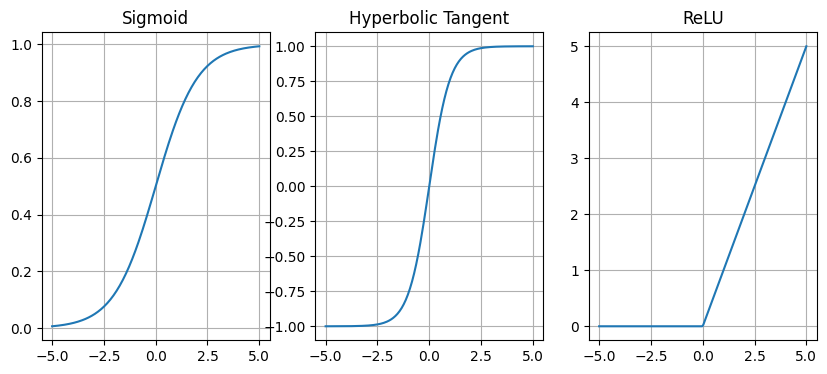

In [13]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,4))

ax[0].plot(x, 1/(1+np.exp(-x)))
ax[0].set_title('Sigmoid')

ax[1].plot(x, np.tanh(x))
ax[1].set_title('Hyperbolic Tangent')

ax[2].plot(x, np.maximum(0, x))
ax[2].set_title('ReLU')

for p in ax:
    p.grid()

#### I am splitting the data into features(all columns besides for y) and target features (y) as well as train (90%) and test(10%) groups.

In [5]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)

#### Specificaly in nueral networks it is crusial to scale the data so some values don't carry more weght that others. I scaled the data using the standard scaler. The testing data is scaled using the parameters of the training set, and not it's own parameters to avoid data leakage.

In [6]:
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# ONLY transform the test data (using training mean/std)
X_test_scaled = scaler.transform(X_test)

#### This cell is the main cell!, the architecture of the network. It specifies how many layers the network has, the amount of neurons in each layer, and how the data is transformed as it passes through the model.

#### All 14 variables are the input for this layer. It is defined with 32 neurons, it is a fully connected layer where every neuron receives input from every neuron in the previous layer.

#### We now add two hidden layers that continue the process of dimensionality reduction and feature extraction. The 32 outputs from the first layer are compressed into 16 and then 8.

#### Since it is a regression model there is one output neuron, the predicted value.



In [7]:
model = Sequential()

# Input layer: 14 features based on your dataset
model.add(Dense(units=32, activation='relu', input_dim=X_train_scaled.shape[1]))

# Hidden layers
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=8, activation='relu'))

# Output layer: 1 unit for numerical prediction
model.add(Dense(units=1, activation=None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### In this section I compile and actually train the model. I am using the Adam optimizer to adjust the weights and MSE to measure how far the predictions are from the real values. The model trains for 50 epochs, looking at the data in batches of 64. I also set aside 10% of the data to validation, to moniter the model's performance on unseen data during the training process.

In [8]:
model.compile(loss='mean_squared_error', optimizer='adam')

# Train for 50 epochs
history = model.fit(X_train_scaled, y_train,
                    epochs=50,
                    batch_size=64,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1500 - val_loss: 0.1054
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0964 - val_loss: 0.0973
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0901 - val_loss: 0.0932
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0872 - val_loss: 0.0916
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0853 - val_loss: 0.0890
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0841 - val_loss: 0.0891
Epoch 7/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0835 - val_loss: 0.0880
Epoch 8/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0827 - val_loss: 0.0878
Epoch 9/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0824 - val_loss: 0.0874
Epoch 10/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0819 - val_loss: 0.0878
Epoch 11/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0817 - val_loss: 0.0874
Epoch 12/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

#### I ma calculating the mean squared error for the training data.

In [11]:
from sklearn.metrics import mean_squared_error

# 1. Generate predictions for the training set
y_train_pred = model.predict(X_train_scaled)

# 2. Calculate the Mean Squared Error for the training set
train_mse = mean_squared_error(y_train, y_train_pred)

print(f"Train MSE: {train_mse}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Train MSE: 0.07395207141623308


#### I am calculating the mean squared error for the testing data. They are close enought to show that the model is not overfitting the training data.

In [9]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

print(f"Test MSE: {mse}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test MSE: 0.09144200096834333


#### In order to see how the model is messing up I plot the predicted values against the residual ( the difference of the actual and predicted value).
#### Te fact that my plot is in a random shape around the line y=0 shows that the model is good and the error is just from backround noise that is unavoidable.

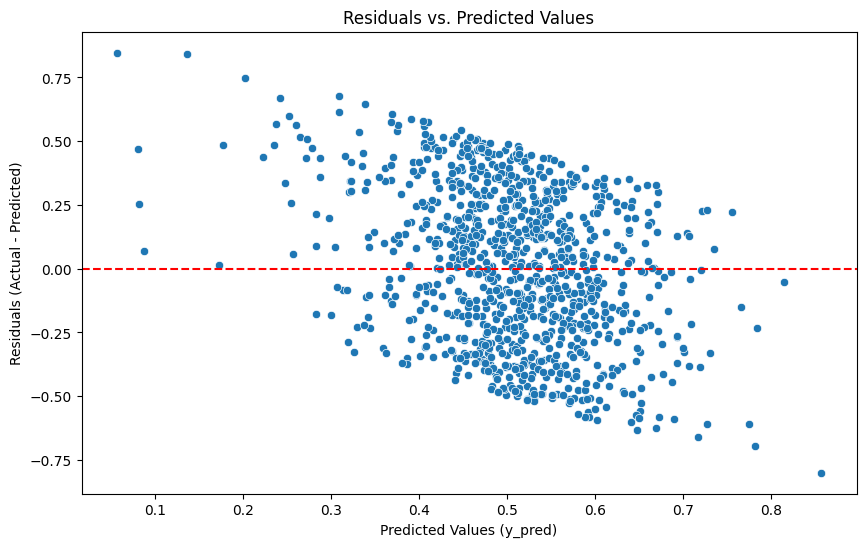

In [10]:
# ---------------------------------------------------------
# Visual Diagnostic: Residual Plot
# ---------------------------------------------------------
residuals = y_test - y_pred.flatten()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred.flatten(), y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values (y_pred)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs. Predicted Values')
plt.show()